# 05 - Demand Forecasting (Phase 5)

Per the project README, Phase 5 is **Demand Forecasting** using
**Prophet / XGBoost** on the Olist data — a time-series problem, not a
row-level regression or classification problem. Price elasticity
(Phase 6) is a separate notebook on the separate Retail Price
Optimization dataset and is out of scope here.

This notebook:
1. Aggregates the item-level `feature_engineered_dataset.csv` (from
   `04_feature_engineering_FIXED.ipynb`) into a **daily demand series**
   (order-item volume + revenue).
2. Splits by date (never randomly — this is time series) into
   train/holdout.
3. Fits **Prophet** on the daily series.
4. Fits **XGBoost** on the same series using lag/calendar features.
5. Compares both on the holdout window using MAE, RMSE, WAPE,
   sMAPE, and MAPE, then saves the best model based on RMSE.

In [12]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

HOLDOUT_DAYS = 30  # last 30 days held out for evaluation

## 1. Load feature-engineered data and rebuild the daily series

`04_feature_engineering_FIXED.ipynb` drops the raw timestamp columns
for the ML feature set but keeps `order_year` / `order_month` /
`order_day` — that's enough to reconstruct a date per row and
aggregate. Demand here is **order-item volume per day** (each row is
one item ordered); revenue is `total_order_value` summed per day.

In [13]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "feature_engineered_dataset.csv"
ml_df = pd.read_csv(DATA_PATH)

ml_df["order_date"] = pd.to_datetime(
    dict(year=ml_df["order_year"], month=ml_df["order_month"], day=ml_df["order_day"])
)

daily = (
    ml_df.groupby("order_date")
    .agg(daily_demand=("order_date", "count"), daily_revenue=("total_order_value", "sum"))
    .reset_index()
    .sort_values("order_date")
)

# Fill any missing calendar days with 0 demand -- a day with no orders
# is a real data point for a forecasting model, not a gap to drop.
full_range = pd.date_range(daily["order_date"].min(), daily["order_date"].max(), freq="D")
daily = (
    daily.set_index("order_date")
    .reindex(full_range)
    .fillna(0.0)
    .rename_axis("order_date")
    .reset_index()
)

print("Date range:", daily["order_date"].min().date(), "to", daily["order_date"].max().date())
print("Days:", len(daily))
daily.head()

Date range: 2016-09-04 to 2018-09-03
Days: 730


,order_date,daily_demand,daily_revenue
0,2016-09-04,2.0,136.23
1,2016-09-05,1.0,75.06
2,2016-09-06,0.0,0.00
3,2016-09-07,0.0,0.00
4,2016-09-08,0.0,0.00


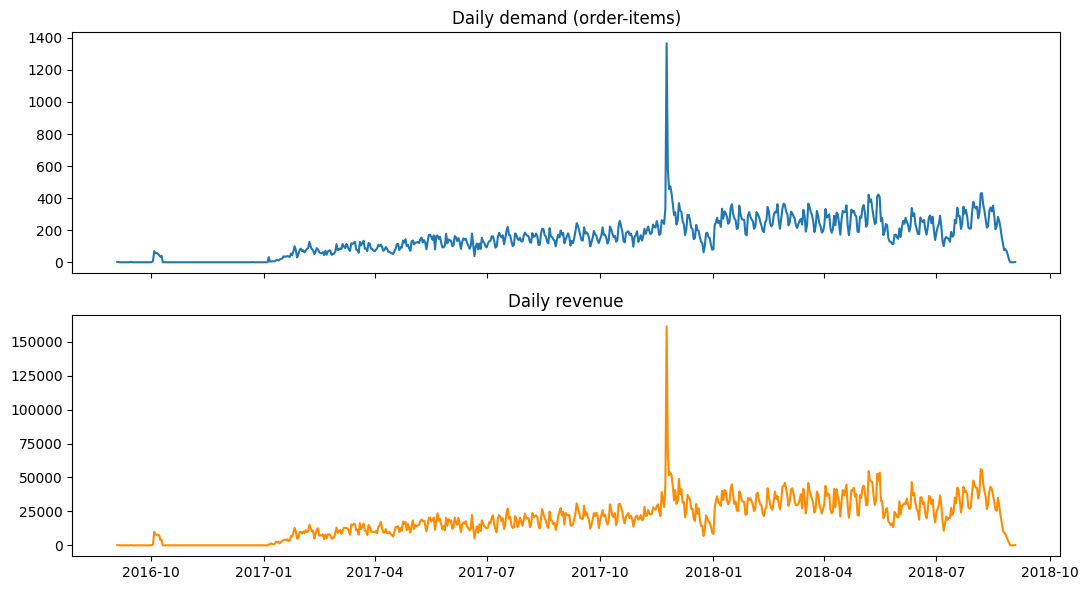

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(daily["order_date"], daily["daily_demand"])
axes[0].set_title("Daily demand (order-items)")
axes[1].plot(daily["order_date"], daily["daily_revenue"], color="darkorange")
axes[1].set_title("Daily revenue")
plt.tight_layout()
plt.show()

## 2. Time-based train / holdout split

In [15]:
if len(daily) <= HOLDOUT_DAYS + 14:
    raise ValueError(
        f"Only {len(daily)} days of data -- not enough for a {HOLDOUT_DAYS}-day holdout "
        "plus a usable training window. Reduce HOLDOUT_DAYS or check the date range above."
    )

split_date = daily["order_date"].iloc[-HOLDOUT_DAYS]
train_df = daily[daily["order_date"] < split_date].copy()
test_df = daily[daily["order_date"] >= split_date].copy()

print(f"Train: {train_df['order_date'].min().date()} -> {train_df['order_date'].max().date()} ({len(train_df)} days)")
print(f"Test:  {test_df['order_date'].min().date()} -> {test_df['order_date'].max().date()} ({len(test_df)} days)")

Train: 2016-09-04 -> 2018-08-04 (700 days)
Test:  2018-08-05 -> 2018-09-03 (30 days)


## 3. Prophet

In [16]:
prophet_train = train_df.rename(
    columns={"order_date": "ds", "daily_demand": "y"}
)[["ds", "y"]]

# We have 700 training days, which is less than ~2 full years.
# Disable yearly seasonality to avoid fitting an unstable annual pattern.
prophet_model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=False,
)

prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(
    periods=HOLDOUT_DAYS,
    freq="D"
)

forecast = prophet_model.predict(future)

prophet_preds = (
    forecast
    .set_index("ds")
    .loc[test_df["order_date"], "yhat"]
    .clip(lower=0)
    .values
)

20:53:15 - cmdstanpy - INFO - Chain [1] start processing
20:53:15 - cmdstanpy - INFO - Chain [1] done processing


### Metric interpretation

Demand forecasting can make MAPE look extremely large when actual
demand is very small, even when the absolute forecast error is
reasonable. Therefore, MAPE is reported for reference but is not used
as the primary model-selection metric.

- **MAE** measures the average absolute forecasting error.
- **RMSE** penalizes larger errors more strongly and is used as the
  primary model-selection metric.
- **WAPE** measures total absolute error relative to total actual demand
  and is useful for business-oriented demand forecasting.
- **sMAPE** provides a symmetric percentage-based error measure.
- **MAPE** is retained for reference but can be unstable when actual
  demand values are small.

In [22]:
def eval_forecast(y_true, y_pred, name):
    """
    Evaluate a demand forecast using metrics that are more appropriate
    for daily demand data.

    MAE  = average absolute error
    RMSE = penalizes larger errors more strongly
    WAPE = total absolute error relative to total actual demand
    sMAPE = symmetric percentage error
    MAPE = reported for reference, but not used as the primary metric
    """

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # WAPE: robust for demand forecasting and avoids
    # dividing by individual small actual values.
    total_actual = np.sum(np.abs(y_true))
    wape = (
        np.sum(np.abs(y_true - y_pred)) / total_actual * 100
        if total_actual > 0
        else np.nan
    )

    # sMAPE: symmetric percentage error.
    denominator = np.abs(y_true) + np.abs(y_pred)
    valid_smape = denominator > 0

    smape = (
        np.mean(
            2 * np.abs(y_true[valid_smape] - y_pred[valid_smape])
            / denominator[valid_smape]
        ) * 100
        if valid_smape.any()
        else np.nan
    )

    # Traditional MAPE is shown only for reference.
    # Zero-demand observations are excluded.
    nonzero = y_true != 0

    mape = (
        np.mean(
            np.abs(
                (y_true[nonzero] - y_pred[nonzero])
                / y_true[nonzero]
            )
        ) * 100
        if nonzero.any()
        else np.nan
    )

    print(
        f"{name:>12} | "
        f"MAE {mae:.2f} | "
        f"RMSE {rmse:.2f} | "
        f"WAPE {wape:.2f}% | "
        f"sMAPE {smape:.2f}% | "
        f"MAPE {mape:.1f}%"
    )

    return {
        "mae": mae,
        "rmse": rmse,
        "wape": wape,
        "smape": smape,
        "mape": mape,
    }


results = {}

results["prophet"] = eval_forecast(
    test_df["daily_demand"].values,
    prophet_preds,
    "Prophet"
)

     Prophet | MAE 111.79 | RMSE 138.42 | WAPE 56.41% | sMAPE 69.65% | MAPE 1108.4%


## 4. XGBoost (lag + calendar features) — chronological FUTURE forecast

**Why this changed:** the first version built lag/rolling features
(`lag_1`, `lag_7`, `rolling_mean_7`, ...) from the full daily series
*before* splitting into train/test. That meant a test-period row's
`lag_1` could be the actual observed demand from the day before it —
inside the test window. That's a valid setup for one-step-ahead
forecasting with feedback, but it is not a genuine multi-day-ahead
forecast, and it's not a fair comparison against Prophet (which never
sees test-period actuals at all).

**Fix — recursive forecasting:** the model is trained only on lag/
rolling features built from `train_df`. To forecast the test horizon,
it predicts one day at a time and feeds its *own prediction* back in
as the lag for the next day — so by the time it forecasts day 10 of
the test window, none of the last 10 days of "history" it's using are
real; they're its own earlier predictions. This is what a true
production forecast looks like: on the day you deploy it, you don't
have next week's actual demand either.

In [18]:
FEATURE_COLS = ["lag_1", "lag_2", "lag_3", "lag_7", "lag_14",
                "rolling_mean_7", "rolling_mean_14",
                "day_of_week", "day_of_month", "month", "is_weekend"]

def build_calendar_features(target_date):
    return {
        "day_of_week": target_date.dayofweek,
        "day_of_month": target_date.day,
        "month": target_date.month,
        "is_weekend": int(target_date.dayofweek >= 5),
    }

def make_training_features(train_series_df, target_col="daily_demand"):
    """Lag/rolling features built ONLY from train_df -- test dates are
    never touched here, so training can't leak future information."""
    df = train_series_df.copy()
    for lag in [1, 2, 3, 7, 14]:
        df[f"lag_{lag}"] = df[target_col].shift(lag)
    df["rolling_mean_7"] = df[target_col].shift(1).rolling(7).mean()
    df["rolling_mean_14"] = df[target_col].shift(1).rolling(14).mean()
    cal = df["order_date"].apply(build_calendar_features).apply(pd.Series)
    df = pd.concat([df, cal], axis=1)
    return df.dropna(subset=FEATURE_COLS)  # first 14 rows lack full lag history

train_features = make_training_features(train_df)
X_train, y_train = train_features[FEATURE_COLS], train_features["daily_demand"]

xgb_model = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE
)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [19]:
def recursive_forecast(model, history_series, horizon, feature_cols):
    """Forecast `horizon` future days one at a time. After each step,
    the model's own prediction (not the real future actual) is appended
    to `history_series` so the NEXT step's lag features are built from
    it -- this is what makes it a genuine multi-day-ahead forecast
    instead of one-step-ahead-with-real-feedback.

    history_series: pd.Series of daily_demand, indexed by date, ending
    the day BEFORE the forecast horizon starts. Must contain at least
    14 days so lag_14 / rolling_mean_14 are defined for day 1.
    """
    history = history_series.copy()
    preds = []
    for _ in range(horizon):
        next_date = history.index[-1] + pd.Timedelta(days=1)
        row = {
            "lag_1": history.iloc[-1], "lag_2": history.iloc[-2], "lag_3": history.iloc[-3],
            "lag_7": history.iloc[-7], "lag_14": history.iloc[-14],
            "rolling_mean_7": history.iloc[-7:].mean(),
            "rolling_mean_14": history.iloc[-14:].mean(),
            **build_calendar_features(next_date),
        }
        X_next = pd.DataFrame([row])[feature_cols]
        pred = max(float(model.predict(X_next)[0]), 0.0)
        preds.append(pred)
        history.loc[next_date] = pred  # feed prediction forward, never a real test actual
    return np.array(preds)

# History available at forecast time = every train-period actual (no test data touched).
history_series = train_df.set_index("order_date")["daily_demand"]
xgb_preds = recursive_forecast(xgb_model, history_series, horizon=len(test_df), feature_cols=FEATURE_COLS)

results["xgboost"] = eval_forecast(test_df["daily_demand"].values, xgb_preds, "XGBoost")

     XGBoost | MAE 100.46 | RMSE 135.38 | WAPE 50.69% | sMAPE 64.74% | MAPE 1258.1%


## 5. Compare & save

Both models forecast the **same future horizon** (the held-out test
dates) without seeing any test-period actuals during prediction —
Prophet by design (it only extends its fitted trend/seasonality
forward), XGBoost via the recursive loop above. They're compared with
`RMSE` as the primary criterion (penalizes large misses more than MAE,
appropriate for demand planning where big misses are costlier than
small ones). The better model is persisted.

In [20]:
best_name = min(
    results,
    key=lambda model_name: results[model_name]["rmse"]
)

print("\nModel comparison")
print("=" * 80)

results_df = pd.DataFrame(results).T

print(
    results_df[
        ["mae", "rmse", "wape", "smape", "mape"]
    ].round(2)
)

print("\nSelected model:", best_name.upper())
print(
    f"Selection criterion: lowest RMSE = "
    f"{results[best_name]['rmse']:.2f}"
)

if best_name == "prophet":
    model_path = MODEL_DIR / "demand_forecast_prophet.pkl"
    joblib.dump(prophet_model, model_path)
else:
    model_path = MODEL_DIR / "demand_forecast_xgboost.pkl"
    joblib.dump(
        {
            "model": xgb_model,
            "feature_cols": FEATURE_COLS,
        },
        model_path,
    )

print(f"Saved -> {model_path}")


Model comparison
            mae    rmse   wape  smape     mape
prophet  111.79  138.42  56.41  69.65  1108.44
xgboost  100.46  135.38  50.69  64.74  1258.08

Selected model: XGBOOST
Selection criterion: lowest RMSE = 135.38
Saved -> d:\pricing-optimization-system\models\demand_forecast_xgboost.pkl


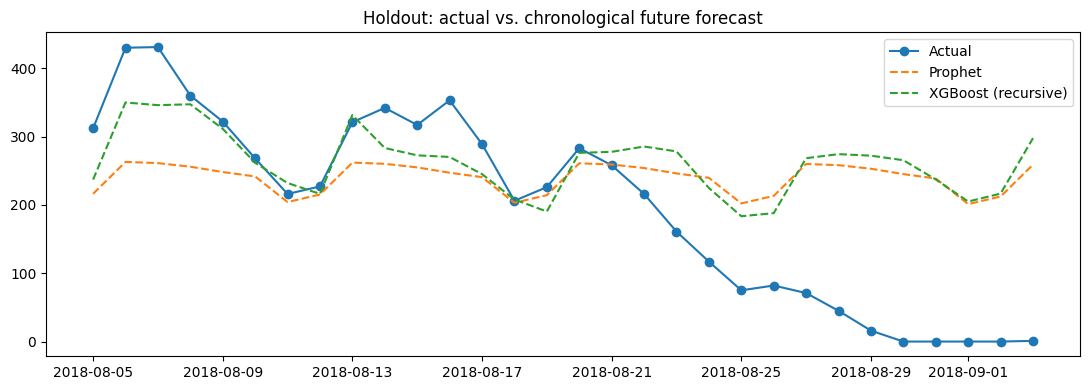

In [21]:
plt.figure(figsize=(11, 4))
plt.plot(test_df["order_date"], test_df["daily_demand"], label="Actual", marker="o")
plt.plot(test_df["order_date"], prophet_preds, label="Prophet", linestyle="--")
plt.plot(test_df["order_date"], xgb_preds, label="XGBoost (recursive)", linestyle="--")
plt.legend()
plt.title("Holdout: actual vs. chronological future forecast")
plt.tight_layout()
plt.show()

## Notes for Phase 6 / 7

- Price elasticity (Phase 6, Statsmodels/EconML) runs on the separate
  **Retail Price Optimization** dataset, not this one — that's a
  different notebook with its own load/clean/feature steps.
- Phase 7 (price optimization, SciPy) combines this demand model with
  the elasticity model from Phase 6 — it needs both to exist first.
- If category-level demand (not just overall) turns out to matter for
  the optimizer, the same daily-aggregation approach here can be
  repeated per `product_category_name` group instead of overall.